In [10]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [11]:
cust_data = pd.read_csv("customer_master.csv")
behave_logs = pd.read_csv("behavioral_log.csv")
cust_trans = pd.read_csv("transaction_ledger.csv")
cust_loans = pd.read_csv("labels.csv")

In [12]:
cust_data.head()

,customer_id,age,occupation_type,employment_tenure_months,city_tier,declared_annual_income,existing_loan_count,existing_loan_types,residence_type,relationship_tenure_years,bureau_score_proxy
0,CUST000001,37,salaried,109,metro,1192000.0,0,NaN,rented,0.5,645
1,CUST000002,26,salaried,17,metro,742000.0,1,auto,owned,5.4,733
2,CUST000003,41,salaried,172,metro,1103000.0,0,NaN,owned,1.6,692
3,CUST000004,42,salaried,130,metro,1494000.0,0,NaN,owned,0.2,690
4,CUST000005,21,salaried,3,metro,861000.0,1,auto,rented,2.4,557


In [13]:
behave_logs.head()

,event_id,customer_id,timestamp,event_type,product_viewed,session_duration_seconds
0,EVT00000023,CUST000001,2025-01-02 12:00:00,app_login,none,105
1,EVT00000066,CUST000001,2025-01-02 21:00:00,app_login,none,214
2,EVT00000009,CUST000001,2025-01-05 17:00:00,app_login,none,258
3,EVT00000012,CUST000001,2025-01-11 15:00:00,app_login,none,267
4,EVT00000069,CUST000001,2025-01-13 14:00:00,app_login,none,299


In [14]:
cust_trans.head()

,transaction_id,customer_id,date,amount,direction,channel,narration_raw,true_category
0,TXN00000001,CUST000001,2024-01-27,93734.80,credit,NEFT,NEFT/416618/SAL/BHARATRETA,salary
1,TXN00000002,CUST000001,2024-01-04,-26319.05,debit,NEFT,NEFT-RENT-LANDLORD-JAN2024,rent
2,TXN00000003,CUST000001,2024-01-29,-837.56,debit,UPI,UPI-SWIGGY-PAYMENT-41682,discretionary
3,TXN00000004,CUST000001,2024-01-19,-557.12,debit,UPI,UPI-BIGBASKET-PAYMENT-93123,discretionary
4,TXN00000005,CUST000001,2024-01-11,-2589.26,debit,UPI,UPI-FLIPKART-PAYMENT-92555,discretionary


In [15]:
cust_loans.head()

,customer_id,applied_flag,converted_flag,loan_type,application_amount
0,CUST000001,0,0,none,0.0
1,CUST000002,1,1,home,1944000.0
2,CUST000003,1,1,personal,1204000.0
3,CUST000004,1,1,mortgage,3268000.0
4,CUST000005,1,1,home,918000.0


In [17]:
master_cust_data = pd.merge(cust_data,cust_loans,on='customer_id',how='outer')
master_cust_data.head()

,customer_id,age,occupation_type,employment_tenure_months,city_tier,declared_annual_income,existing_loan_count,existing_loan_types,residence_type,relationship_tenure_years,bureau_score_proxy,applied_flag,converted_flag,loan_type,application_amount
0,CUST000001,37,salaried,109,metro,1192000.0,0,NaN,rented,0.5,645,0,0,none,0.0
1,CUST000002,26,salaried,17,metro,742000.0,1,auto,owned,5.4,733,1,1,home,1944000.0
2,CUST000003,41,salaried,172,metro,1103000.0,0,NaN,owned,1.6,692,1,1,personal,1204000.0
3,CUST000004,42,salaried,130,metro,1494000.0,0,NaN,owned,0.2,690,1,1,mortgage,3268000.0
4,CUST000005,21,salaried,3,metro,861000.0,1,auto,rented,2.4,557,1,1,home,918000.0


In [19]:
master_cust_data.drop('existing_loan_types',axis=1)

,customer_id,age,occupation_type,employment_tenure_months,city_tier,declared_annual_income,existing_loan_count,residence_type,relationship_tenure_years,bureau_score_proxy,applied_flag,converted_flag,loan_type,application_amount
0,CUST000001,37,salaried,109,metro,1192000.0,0,rented,0.5,645,0,0,none,0.0
1,CUST000002,26,salaried,17,metro,742000.0,1,owned,5.4,733,1,1,home,1944000.0
2,CUST000003,41,salaried,172,metro,1103000.0,0,owned,1.6,692,1,1,personal,1204000.0
3,CUST000004,42,salaried,130,metro,1494000.0,0,owned,0.2,690,1,1,mortgage,3268000.0
4,CUST000005,21,salaried,3,metro,861000.0,1,rented,2.4,557,1,1,home,918000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST004996,43,business_owner,129,metro,425000.0,0,owned,0.5,581,0,0,none,0.0
4996,CUST004997,32,salaried,31,tier3,553000.0,0,owned,5.5,547,0,0,none,0.0
4997,CUST004998,41,salaried,112,tier2,318000.0,0,owned,13.7,585,1,1,mortgage,741000.0
4998,CUST004999,35,salaried,49,tier2,701000.0,1,owned,1.5,703,0,0,none,0.0


C:\Users\aleem\AppData\Local\Temp\ipykernel_4772\3533978832.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'existing_loan_count',y = 'city_tier',data=master_cust_data,estimator='sum',palette='mako')


<Axes: xlabel='existing_loan_count', ylabel='city_tier'>

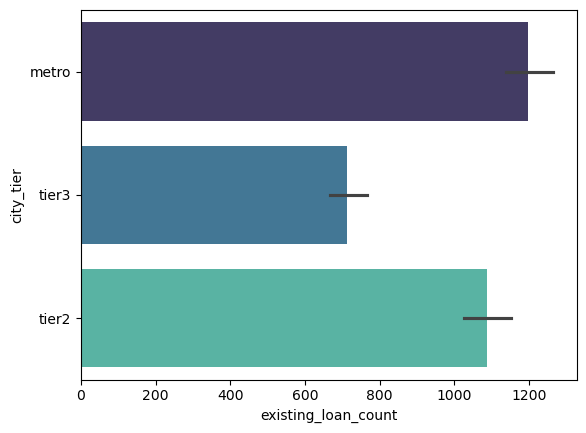

In [23]:
sns.barplot(x = 'existing_loan_count',y = 'city_tier',data=master_cust_data,estimator='sum',palette='mako')

<Axes: xlabel='age', ylabel='declared_annual_income'>

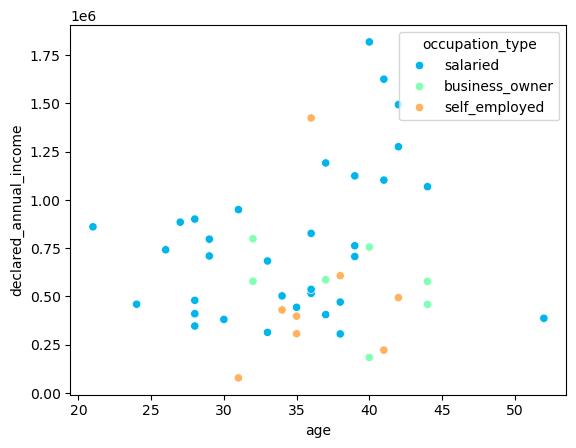

In [27]:
sns.scatterplot(x = 'age', y = 'declared_annual_income',data=master_cust_data.head(50),hue='occupation_type',palette='rainbow')

<Axes: xlabel='application_amount', ylabel='loan_type'>

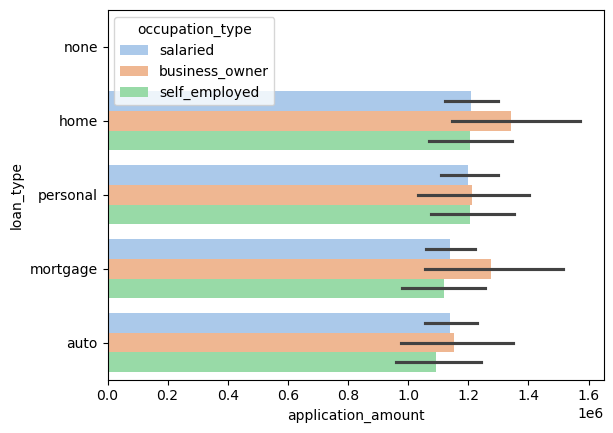

In [34]:
sns.barplot(x='application_amount',y='loan_type',data=master_cust_data,hue='occupation_type',palette='pastel')

<Axes: xlabel='age', ylabel='declared_annual_income'>

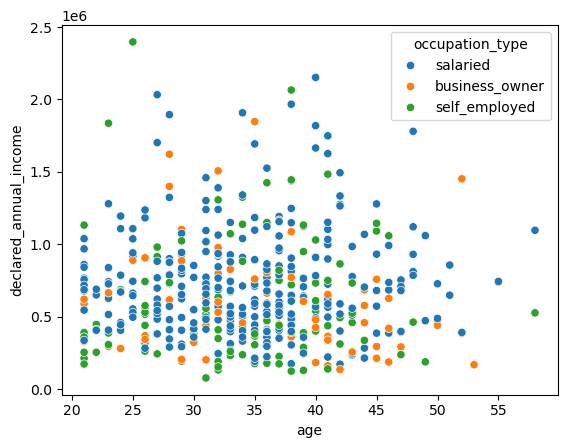

In [38]:
sns.scatterplot(x = 'age',y='declared_annual_income',data=master_cust_data.head(500),hue='occupation_type')